In [92]:
using Plots
using LaTeXStrings
include("fft.jl")
# using FFTW
# function fft2(image)
#     return fftshift(fft(ifftshift(image)))
# end

ifft2 (generic function with 1 method)

In [93]:
function fftfreq(n::Int, d::Real=1)
    val = 1.0 / (n * d)
    N = div(n, 2)
    if iseven(n)
        return vcat(0:N-1, -N:-1) * val
    else
        return vcat(0:N, -(N): -1) * val
    end
end

fftfreq (generic function with 2 methods)

In [94]:
function Wavelength(E::T) where T <: Real
    hc::T = 12.398 #keV*Angstrom
    # h = 6.582119e-16 #eV*sec
    # mc2 = 511 #keV
    E₀::T = 511.0 #keV
    return hc/sqrt(abs(E*(2*E₀ + E)))
end


function Focus(E::T, Cs::T, nᵢ=1)::T where T <: Real
    return sqrt((2*nᵢ-0.5)*Cs*Wavelength(E))
end
kmax(E, Cs) = (6/((Cs*Wavelength(E)^3)))^(1/4)

Diff_Image(image, c=0.1) = @. log1p(c*abs(image))

Diff_Image (generic function with 2 methods)

In [95]:
E = 300.0 #keV
Cs = 1 #mm
Cs = Cs * 1e7 #convert to Angstroms

N = 2^10
physical_scale = 1
camera_scale = 2

upper = (N-1)/2 + 0.1
lower = (-N+1)/2
kx = collect(lower:1:upper)
ky = collect(lower:1:upper)

r = @. sqrt(kx'^2 + ky^2)
disk_scale = 1
disk = r.<=N/2/disk_scale

λ(E) = Wavelength(E)
Δf(E, Cs) = Focus(E, Cs)
χ(k) = @. π*λ(E)*k^2*(0.5*Cs*λ(E)^2*k^2 - Δf(E, Cs))


χ (generic function with 1 method)

\begin{align*}
    u, v \to \frac{x}{\lambda  f}, \frac{y}{\lambda  f}, 
\end{align*}

In [96]:
σ(E) = 2π/(Wavelength(E)*E) * (511 + E)/(2*511 + E)
"""
lets estimate n and κ from CjW thesis. Lets assume there is a 10 phase_reconstruced
decay and pi/2 phase shift after 50nm
"""
λ_nm = Wavelength(E)/10 # convert to nm
#given
σU = 0.15 
α = 0.008 
distance_est = 50 #nm
κ = α * (λ_nm/(2*π)) # this is the attenuation coefficient 


"""
Assuming that CJW uses 300keV electrons
"""
σ_cjw = σ(300.0) * 10 # per nm 
U_mip = σU/σ_cjw 
println(κ,"  ", U_mip)
# κ = 0

2.5066020800003746e-6  0.022983624805675437


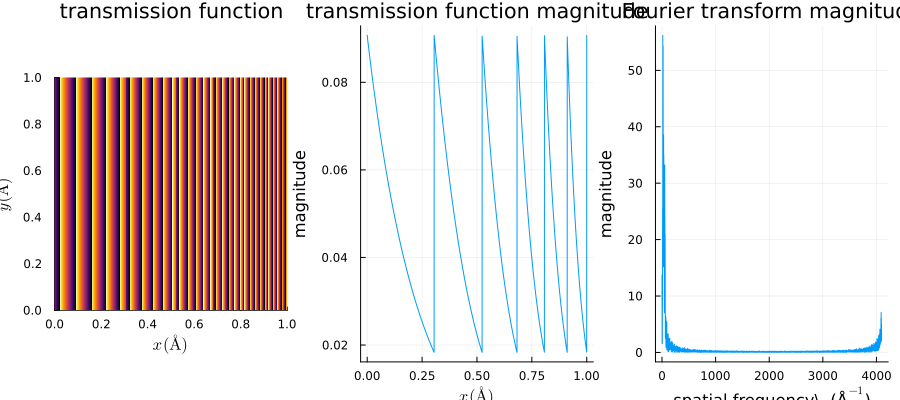

In [97]:
q = range(0, stop=1, length=N*4)
p = 3
g1 = @. 200*mod(p*(q + q^3),1) + 300 # in nm
t1 = @. cis((σU + 1im * α)*g1)
ft_t1 = fft(t1) 
t1 = repeat(t1', length(q), 1)      # -> N×N
fig0 = heatmap(q, q, angle.(t1), title="transmission function", aspect_ratio=1,
        xlabel=L"x\, (Å)", ylabel=L"y\, (Å)", colorbar=false)
xlims!(fig0, (0,1))
ylims!(fig0, (0,1))
fig1 = plot(q, abs.(t1[1,:]), title="transmission function magnitude",
        xlabel=L"x\, (Å)", ylabel="magnitude", legend=false)

fig2 = plot(abs.(ft_t1), title="Fourier transform magnitude",
        xlabel=L"spatial frequency\, (Å$^{-1}$)", ylabel="magnitude", legend=false)

plot(fig0, fig1, fig2, layout=(1,3), size=(900,400))

In [ ]:
ft_t1 = fftshift(fft(ifftshift(t1)))
fig3 = plot(q, abs.(ft_t1[N÷2 + 1,:]), title="Fourier transform magnitude (fftshifted)",
        xlabel=L"spatial frequency\, (Å$^{-1}$)", ylabel="magnitude", legend=false)
fig4 = plot(q, angle.(ft_t1[N÷2 + 1,:]), title="Fourier transform phase (fftshifted)",
        xlabel=L"spatial frequency\, (Å$^{-1}$)", ylabel="phase", legend=false)
plot(fig3, fig4, layout=(1,2), size=(800,400))

In [ ]:
fig5 = zoom_heatmap(q, q, abs.(ft_t1), 200, title="Fourier transform phase (fftshifted)",
        xlabel=L"spatial frequency\, (Å$^{-1}$)", ylabel=L"spatial frequency\, (Å$^{-1}$)", colorbar=false)
# xlims!(fig5, (0,1))
ylims!(fig5, (0.495,0.505))
plot(fig5, size=(400,400))

In [ ]:
function blazed_rdgrating(p; thickness=500, mill_depth=208, reversed=false)
    rs = @. r/N*2
    d0 = thickness - mill_depth
    if !reversed
        g1 = @. mill_depth * mod(p*rs, 1) + d0
    else
        g1 = @. mill_depth * (1 - mod(p*rs, 1)) + d0
    end
    return g1
end

In [ ]:
ψ_grating = blazed_rdgrating(16; thickness=500, mill_depth=208, reversed=true)
heatmap(ψ_grating)

In [ ]:
function blazed_2dgrating(p; thickness=500, mill_depth=208)
    """
        thickness = 500 #Angstroms
        mill_depth = 208 #Angstroms
    """

    xs = (0:N-1) ./ N                # N points, endpoint 1 is excluded
    d0 = thickness - mill_depth
    g1 = @. mill_depth*mod(p*xs, 1) + d0
    # idx = 0:N-1
    # g1  = mill_depth .* (idx .% (N ÷ p)) ./ (N ÷ p) .+ d0
    g2 = repeat(g1', N, 1)
    return g2
end
periods = 16*disk_scale
ψ_grating = @. cis((σ(E)*U_mip+1im*κ*2π/Wavelength(E))*$blazed_2dgrating(periods)*disk) * disk;

"""
    I believe that my kappa and U_mip values are wrong since using just the values reported in CJW, the results are very different
"""
x = collect(range(-10e4, 10e4, N))
y = copy(x)
ΔL = x[2] - x[1]

ψ_grating = @. cis((σU + 1im * α)*$blazed_2dgrating(periods)/10 * disk) * disk
# ψ_grating = @. cis((σU + 1im * α)*$blazed_2dgrating(periods)/10 ) 

# ψ_grating = @. cis((σU )*$blazed_2dgrating(periods)/10 ) 
ψ_grating /= sqrt(sum(abs2,disk) * ΔL^2)
println(sum(abs2,ψ_grating)*ΔL^2);
plot(abs.(ψ_grating[N÷2+1,:]))
plot!(abs.(reverse(ψ_grating[N÷2+1,:])))


In [ ]:
function zoom_in(image::AbstractMatrix, width = 50)
    N = size(image, 1)
    center = div(N, 2) + 1
    half_width = div(width, 2)
    return image[center-half_width:center+half_width, center-half_width:center+half_width]
end

function zoom_in(x::AbstractVector, y::AbstractVector, image::AbstractMatrix, width = 50)
    N = size(image, 1)
    center = div(N, 2) + 1
    half_width = div(width, 2)
    x_zoomed = x[center-half_width:center+half_width]
    y_zoomed = y[center-half_width:center+half_width]
    # , xlims=(x_zoomed[1], x_zoomed[end]), ylims=(y_zoomed[1], y_zoomed[end])
    return x_zoomed, y_zoomed, image[center-half_width:center+half_width, center-half_width:center+half_width]

end

function zoom_heatmap(x::AbstractVector, y::AbstractVector, image::AbstractMatrix, width=50; kwargs...)
    N = size(image, 1)
    center = div(N, 2) + 1
    half_width = div(width, 2)
    
    x_zoomed = x[center-half_width:center+half_width]
    y_zoomed = y[center-half_width:center+half_width]
    image_zoomed = image[center-half_width:center+half_width, center-half_width:center+half_width]
    
    return heatmap(x_zoomed, y_zoomed, image_zoomed; xlims=(x_zoomed[1], x_zoomed[end]), ylims=(y_zoomed[1],y_zoomed[end]), kwargs...)
end
function zoom_in(x::AbstractVector, y::AbstractVector, width = 20)
    N = length(y)
    ctr = N÷2 + 1
    half_width = width ÷ 2
    x_zoomed = x[ctr-half_width:ctr+half_width]
    y_zoomed = y[ctr-half_width:ctr+half_width]
    return x_zoomed, y_zoomed
end

function transform_coordinates(x, y, E, f)
    """
    transform x and y coordinates from front focal plane to back focal plane. it assumes that
    the ff-plane coordinates and focal point are in units of Angstroms. E is units of keV.
    """
    ΔLx, ΔLy = x[2] - x[1], y[2] - y[1]
    Nx, Ny = length(x), length(y)
    kx, ky = fftshift(fftfreq(Nx, ΔLx)), fftshift(fftfreq(Ny, ΔLy))
    kx_transformed = @. kx * Wavelength(E) * f
    ky_transformed = @. ky * Wavelength(E) * f
    return kx_transformed, ky_transformed
end
function chain_transforms(x0, y0, focal_lengths, E)
    coords = []
    x, y = x0, y0
    push!(coords, (x, y))
    for f in focal_lengths
        x, y = transform_coordinates(x, y, E, f)
        push!(coords, (x, y))
    end
    return coords
end

In [ ]:
function radial_grid(x,y)
    Nx, Ny = length(y), length(x)

    upperx = (Nx-1)/2 + 0.1
    lowerx = (-Nx+1)/2
    rx = collect(lowerx:1:upperx)

    uppery = (Ny-1)/2 + 0.1
    lowery = (-Ny+1)/2
    ry = collect(lowery:1:uppery)

    return @. sqrt(rx'^2 + ry^2)
end

function radial_disks(coords, disk_rel_scales)
    r_dists = [(@. sqrt(x'^2 + y^2)) for (x,y) in coords[1:3]]
    r_ratios = [maximum(r_dist)/maximum(r_dists[1]) for r_dist in r_dists]
    
    r = radial_grid(coords[1]...)
    disks = [r.<=N/2/ratio * disk_rel_scales[i] for (i,ratio) in enumerate(r_ratios)]
    return disks, r_dists
end


function double_grating(x1, y1, ψ_1stgrating, ψ_2ndgrating; aberrations=false, focal_lengths::Vector, aperature=true, phase_shift=0)
    """
        This function will propagate a plane wave incident on g1 into plane_1, interact with the sample, 
        propagate again into plane_2, interact with g2, and finally propagate again into plane_3 (image plane).

        There are 3 total propagations.
    """
    crds = chain_transforms(x1, y1, focal_lengths, E)
    dx2 = [(x[2] - x[1]) * (y[2] - y[1]) for (x,y) in crds]

    disk_rel_scales = [1, 5, 1]
    disks, r_dists = radial_disks(crds, disk_rel_scales)
    disks = aperature ? disks : [trues(size(disk)) for disk in disks]

    probe_mask = @. sqrt(x1'^2 + y1^2) < periods÷2 * sqrt(dx2[1])
    probe_mask = circshift(probe_mask, (0, periods))


    
    H = [aberrations ? (@. exp(-1im*χ(r_dists[i]/(f*λ(E)))*disks[i])*disks[i]) : ones(N,N) for (i,f) in enumerate(focal_lengths)]

    
    ψ_1stgrating = @. cis((σU + 1im * α)*$blazed_2dgrating(periods)/10 * disks[1]) * disks[1]
    # ψ_1stgrating = @. cis((σU + 1im * α)*$blazed_rdgrating(periods)/10 ) * disks[1]
    ψ_1stgrating /= sqrt(sum(abs2, ψ_1stgrating) * dx2[1])
    ψ_2ndgrating = @. cis((σU + 1im * α)*$blazed_2dgrating(periods*focal_lengths[2]/focal_lengths[1])/10 * disks[3]) * disks[3]
    # ψ_2ndgrating = @. cis((σU + 1im * α)*$blazed_rdgrating(periods*focal_lengths[2]/focal_lengths[1], reversed=true)/10 * disks[3]) * disks[3]

    ψ_2ndgrating /= sqrt(sum(abs2, disks[3]) * dx2[3])
    
    ψ_1m = ones(N, N) 
    ψ_1p = ψ_1stgrating.*H[1]
    ψ_1p ./= sqrt(sum(abs2, ψ_1p) * dx2[1])

    ψ_2m = fft2(ψ_1p)*dx2[1] /(1im * Wavelength(E) * focal_lengths[1]);
    # phase_shift = π
    probe_phase_shift = @. cis(probe_mask * phase_shift) #general phase shift
    # probe_phase_shift = .~probe_mask
    ψ_2p = ψ_2m .* probe_phase_shift

    ψ_3m = ifft2(ψ_2p.*H[2])*dx2[2] /(1im * Wavelength(E) * focal_lengths[2]) * reduce(*, size(ψ_2p));
    ψ_3m = reverse(ψ_3m)
    ψ_probability = (sum(abs2, ψ_3m.*disks[3]) * dx2[3]) * (sum(abs2, ψ_2ndgrating.*disks[3]) * dx2[3])
    ψ_3p = ψ_3m .* ψ_2ndgrating
    ψ_3p .*= sqrt(ψ_probability/(sum(abs2, ψ_3p) * dx2[3]))

    
    ψ_4m = fft2(ψ_3p.*H[3])*dx2[3] /(1im * Wavelength(E) * focal_lengths[3]);
    ψs = [ψ_1m, ψ_1p, ψ_2m, ψ_2p, ψ_3m, ψ_3p, ψ_4m]
    idx = [1, 1, 2, 2, 3, 3, 4]
    probs = [sum(abs2, ψ) * dx2[idx[i]] for (i,ψ) in enumerate(ψs)]
    return ψs, probs, H, crds, dx2
end

In [ ]:

aberrations = true
focal_lengths = [1e10, 1e10, 1e10] # in Angstroms

crds = chain_transforms(x, y, focal_lengths, E)
disk_rel_scales = [1, 2, 1]
disks, r_dists = radial_disks(crds, disk_rel_scales)
dx2 = [(x[2] - x[1]) * (y[2] - y[1]) for (x,y) in crds]




In [ ]:
ψs, probs, Hs, crds, dx2 = double_grating(x, y, ψ_grating, ψ_grating; 
                            aberrations=aberrations, 
                            focal_lengths=focal_lengths, 
                            aperature=true,
                            phase_shift=0);
println(probs)


In [ ]:
idx = 3
heatmap(crds[idx]...,angle.(ψs[idx]))

In [ ]:

fig1 = heatmap(crds[1]...,angle.(ψs[2]), title="front focal plane", 
        xlabel=L"x\, (Å)", ylabel=L"y\, (Å)", aspect_ratio=1, colorbar=false, xlims=(x[1],x[end]),ylims=(y[1],y[end]))

fig2 = zoom_heatmap(crds[1]..., angle.(ψs[3]), 50, 
                   title="back focal plane", 
                   xlabel=L"x\, (Å)", ylabel=L"y\, (Å)", 
                   aspect_ratio=1, colorbar=false)

fig3 = zoom_heatmap(crds[1]..., Diff_Image(ψs[3]), 50,
                   title="back focal plane magnitude", 
                   xlabel=L"x\, (Å)", ylabel=L"y\, (Å)", 
                   aspect_ratio=1, colorbar=true)
plot(fig1, fig2, fig3, layout=(1, 3), size=(1200, 600))

\begin{align*}
    \int f(x,y) dx^2 \approx \sum_{i,j} f(x_i,y_j) \Delta x \Delta y
\end{align*}

In [ ]:
fig1 = zoom_heatmap(crds[1]..., abs.(ψs[3]).*probe_mask, 50,
                   title="back focal plane magnitude", 
                   xlabel=L"x\, (Å)", ylabel=L"y\, (Å)", 
                   aspect_ratio=1, colorbar=false)

fig2 = zoom_heatmap(crds[1]..., probe_mask, 50,
                         title="sample plane magnitude", 
                   xlabel=L"x\, (Å)", ylabel=L"y\, (Å)", 
                   aspect_ratio=1, colorbar=false)
plot(fig1, fig2, layout=(1, 2), size=(800, 400))

In [ ]:

plot(abs.(ψs[5][N÷2+1,:]))
plot!(abs.(ψ_grating[N÷2+1,:]).*1.3)
ymin,ymax = ylims()
ylims!(ymax*0.6, ymax)  # or use a specific upper value

In [ ]:



fig1 = heatmap(crds[3]...,angle.(ψs[5]), aspect_ratio=:equal)
fig2 = heatmap(crds[1]..., abs2.(ψs[6]), aspect_ratio=:equal)
plot(fig1, fig2, layout=(1,2), size = (1200,600))

In [ ]:
fig1 = zoom_heatmap(crds[4]..., Diff_Image(ψs[7],0.001), 100, colorbar=false)
fig2 = plot(zoom_in(crds[4][1], vec(sum(abs2, ψs[7], dims=1).*dx2[4]), 100)...)
vline!(fig2, [x[N÷2+1] + 16*sqrt(dx2[4])], lw=2, lc=:red)
plot(fig1, fig2, layout=(1,2), size = (1200, 600))


In [ ]:
ψs_1d = vec(sum(abs2, ψs[7], dims=1).*dx2[4])
println(x[N÷2+1])
println(x[N÷2+5])
println(16*sqrt(dx2[4]))
peak_locs = collect(range(minimum(x), maximum(x) ; step=16*sqrt(dx2[4])))
peak_locs .-= peak_locs[length(peak_locs)÷2+1]
peak_indices = [findmin(abs.(x .- loc))[2] for loc in peak_locs]
peak_idxspacing = floor(Int, (peak_locs[2] - peak_locs[1])/(x[2]-x[1]))
peak_idxspacing = 16
peak_masks = [begin
    mask = falses(N)
    mask[clamp(peak_idx - peak_idxspacing ÷ 2, 1, N):clamp(peak_idx + peak_idxspacing ÷ 2, 1, N)] .= true
    mask
end for peak_idx in peak_indices]

println(peak_indices)
println(peak_idxspacing)
println(x[peak_indices])
println(peak_locs)
println(peak_locs[length(peak_locs)÷2+1])
mode_probs = [sum(ψs_1d[mask]) for mask in peak_masks]
println(mode_probs)
println(sum(mode_probs), " ", sum(abs2,ψs[7])*dx2[4])
println(mode_probs[7])
println(ψs_1d[peak_indices])

In [ ]:
using Statistics
function Periodic_Peaks(y::AbstractVector)
    idx = 1:length(y)
    threshold = maximum(y)/5
    y_tmp = y.-threshold
    interceptions = []


    for i in 1:(length(y)-1)
        if y_tmp[i+1]*y_tmp[i] < 0
            dfdx = y_tmp[i+1]-y_tmp[i]
            x0 = idx[i] - y_tmp[i]/dfdx
            push!(interceptions, x0)
        end
    end
    Δx = median(interceptions[2:end] .- interceptions[1:end-1])/2
    peaks = @. round(Int, interceptions[1:2:end-1] + Δx)
    peak_spacing = round(Int, median(peaks[2:end] .- peaks[1:end-1]))

    return peaks, peak_spacing
end

In [ ]:
prob2d = @. abs2(ψs[7]) * dx2[4]
autocorr = abs.(ifft2(fft2(prob2d).*fft2(prob2d)))

peaks, peak_spacing = Periodic_Peaks(autocorr[N÷2+1, :])

mask = N÷2+1-80:N÷2+1+80
plot((1:N)[mask], autocorr[N÷2+1, mask])
scatter!(peaks, [autocorr[N÷2+1,peak] for peak in peaks], ms=4, mc=:red, label="autocorr peaks")


In [ ]:

ψs_1d = vec(sum(abs2, ψs[7], dims=1).*dx2[4])

peaks, peak_spacing = Periodic_Peaks(ψs_1d)

mask = N÷2+1-80:N÷2+1+80
plot((1:N)[mask], ψs_1d[mask])
scatter!(peaks, [ψs_1d[peak] for peak in peaks], ms=4, mc=:red, label="autocorr peaks")

In [ ]:
while peaks[end] + peak_spacing < N
    push!(peaks, peaks[end] + peak_spacing)
end
while peaks[1] - peak_spacing > 1
    pushfirst!(peaks, peaks[1] - peak_spacing)
end

In [ ]:
peak_masks = [begin
    mask = falses(N)
    mask[clamp(peak_idx - peak_spacing ÷ 2, 1, N):clamp(peak_idx + peak_spacing ÷ 2, 1, N)] .= true
    mask
end for peak_idx in peaks]
mode_probs = [sum(ψs_1d[mask]) for mask in peak_masks]
println(sum(mode_probs), findmax(mode_probs))


In [ ]:
bar(1:length(mode_probs), mode_probs, xlabel="mode index", ylabel="mode probability", legend=false)
width = 6
xlimits = [-width÷2, width÷2 ] .+ (length(mode_probs)÷2)
xlims!(xlimits...)   

In [ ]:
Prob_dp = sum(mode_probs) - mode_probs[length(mode_probs)÷2+1]
Prob_int = 0.52
η = Prob_dp / (Prob_dp + Prob_int)

In [ ]:
fig1 = zoom_heatmap(x,y, angle.(ψs[3]), 80, colorbar=false)
fig2 = zoom_heatmap(x,y, abs2.(ψs[3]), 80, colorbar=false)
plot(fig1, fig2, layout=(1,2), size=(800,400))

In [ ]:
kernel = ψs[3] 
mask = @. (x' + y^2*0) > -periods÷2 * sqrt(dx2[1])
mask_complex = mask
ang = angle.(kernel)
ang .= ang.*mask
kernel_mask = abs.(kernel).*mask .* cis.(ang)
fig1 = zoom_heatmap(x,y, abs.(kernel_mask), 100, colorbar=true)


In [ ]:
fft_kernel_mask = fft2(kernel_mask)
fig2 = zoom_heatmap(x,y, abs.(fft_kernel_mask), 150, colorbar=true)
plot(fig1, fig2, layout=(1,2), size=(800,400))